In [22]:
import torch
import torch.nn as nn

In [23]:

from torchvision import datasets, transforms
import torch.utils.data as dataload

In [24]:
# The transforms we need:
# to tensor (0-1 values, permutes channels?)
data_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1307], std=[0.3081])
])

In [25]:
# Now we import training data
training_data = datasets.MNIST(
    root="./data",
    # Give all training images
    train=True,
    # download
    download=True,
    # apply transforms
    transform=data_transforms
)

# Btw it downloads (training data + test data) * labels

In [26]:
training_loader = dataload.DataLoader(
    dataset=training_data,
    batch_size=64,
    shuffle=True, # Every epoch randomize batch order
    num_workers=4 # subprocess for parallel loading
)

In [27]:
# now deal with test data. Extract that.
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=data_transforms)
test_loader = dataload.DataLoader(
    dataset=test_data,
    batch_size=1000,
    shuffle=False
)


In [28]:
class MNIST(nn.Module):
    def __init__(self):
        super().__init__() # Calling nn.module constructor
        # Now the big thing: making a convolutional layer
        # out channels is number of different filters we want
        # padding increases from 26 --> 28
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Now we create 2nd convolution
        # More filters 32 --> 64, and still keeping 14 x 14
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # Okay, but now we need to pool again.
        # As filters increase, the maps get smaller
        # Theortically you can reuse the pooling, but i don't realy want to
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Linear flattens it (64 * 7 * 7 to 3136)
        # Then we have standard 3136 to 128 dense layer. All patterns are learned here
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        # Very confusing... takes size of first (64), -1 does all the math (64 * 7 * 7?). So this flattens it. and you are
        # doing it in batches
        x = x.view(x.size(0), -1)
        # now 64 x 128
        x = torch.relu(self.fc1(x))
        # now do the second fc2, 128 to 10...
        x = self.fc2(x)
        return x






In [29]:
device = torch.device('mps')
# moves model onto chosen device
model = MNIST().to(device)
print(model)

MNIST(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [30]:
# Applies softmax function, as well as does loss function stuff
criterion = nn.CrossEntropyLoss()
# now the optimizer: the actual traning model
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [31]:
# training loop
num_epochs = 10

for epoch in range(num_epochs):
    # gets it in model mode, doesn't do anything
    model.train()
    # gives 64 images, runnings about 937 times
    running_loss = 0.0
    for images, labels in training_loader:
        # moves onto same device model
        images, labels = images.to(device), labels.to(device)
        # reset gradients
        optimizer.zero_grad()
        outputs = model(images)
        # finds loss. applies softmax function
        loss = criterion(outputs, labels)
        # Back propogation: calculate gradient for every weight
        # the insane step..
        loss.backward()
        # Now makes a step (updates all weights)
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(training_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.10f}")
torch.save(model.state_dict(), 'mnist_cnn.pth')


Epoch 1/10, Loss: 0.1734282449
Epoch 2/10, Loss: 0.0515046560
Epoch 3/10, Loss: 0.0357657816
Epoch 4/10, Loss: 0.0259736243
Epoch 5/10, Loss: 0.0196901226
Epoch 6/10, Loss: 0.0155809242
Epoch 7/10, Loss: 0.0130318921
Epoch 8/10, Loss: 0.0093427636
Epoch 9/10, Loss: 0.0074060996
Epoch 10/10, Loss: 0.0076882248


In [32]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.08%


In [35]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [33]:
import itertools
# we don't wanna load the whole thing to memory yet
named_params = model.named_parameters()

first_10 = dict(itertools.islice(named_params, 10))

for key, value in first_10.items():
    print(f"Name: {key}, Parameter: {value}")

Name: conv1.weight, Parameter: Parameter containing:
tensor([[[[ 0.1879,  0.2364, -0.2844],
          [-0.1911,  0.2843, -0.0058],
          [-0.1128,  0.2784,  0.0398]]],


        [[[ 0.3747,  0.2462, -0.3949],
          [ 0.1275,  0.1407, -0.4568],
          [ 0.3049, -0.3334, -0.0623]]],


        [[[ 0.2183, -0.1325,  0.2355],
          [-0.1109,  0.2530,  0.2831],
          [-0.4085, -0.1630,  0.1475]]],


        [[[-0.0151, -0.1100, -0.3150],
          [-0.0240, -0.3575,  0.3044],
          [ 0.2587,  0.1144,  0.1588]]],


        [[[-0.3590,  0.0112, -0.3486],
          [-0.3386,  0.1251, -0.1227],
          [ 0.2482, -0.3273, -0.2552]]],


        [[[ 0.0894, -0.2170, -0.3982],
          [ 0.3640,  0.0598, -0.1018],
          [-0.0674,  0.3400,  0.1976]]],


        [[[ 0.2917, -0.2481,  0.0397],
          [ 0.2236, -0.4786,  0.0934],
          [-0.0805, -0.3277,  0.4605]]],


        [[[ 0.0516,  0.1110,  0.2641],
          [-0.1860,  0.2203,  0.2847],
          [-0.4284, -0

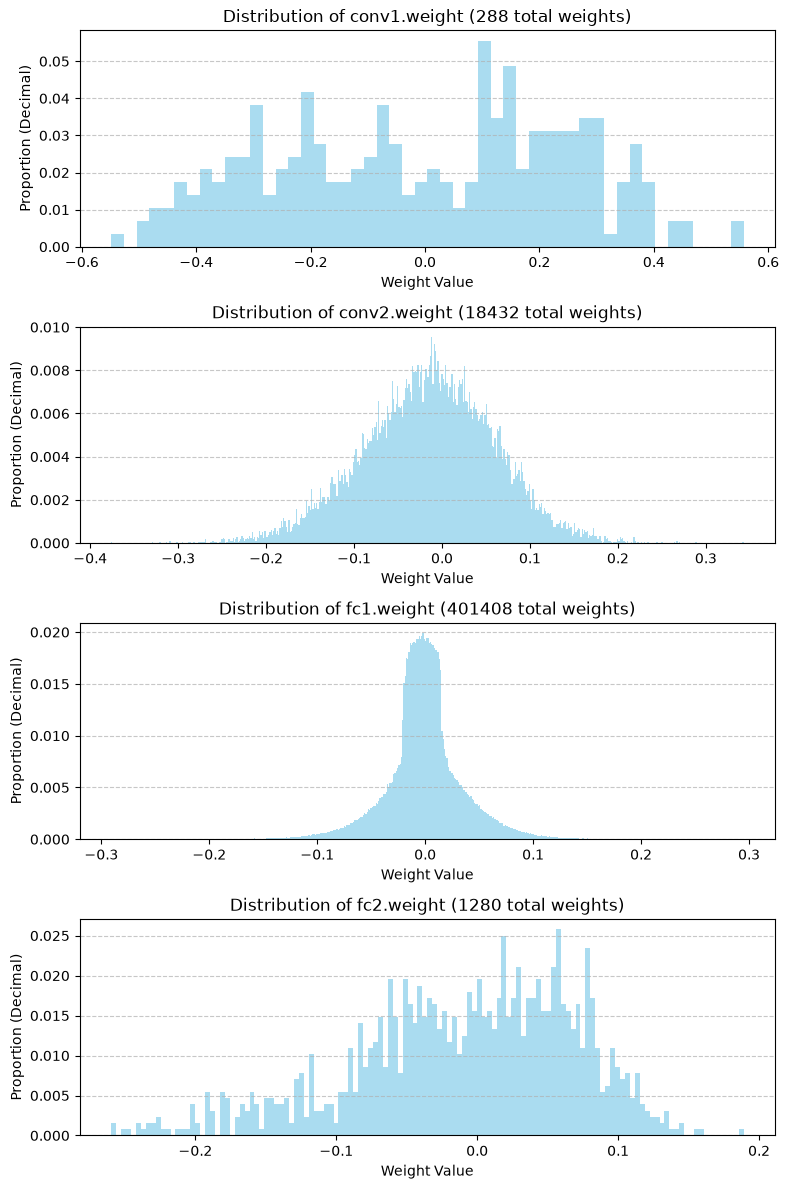

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_weight_distribution(model):
    layers_with_weights = [
        (name, param) for name, param in model.named_parameters() if "weight" in name
    ]

    num_layers = len(layers_with_weights)
    if num_layers == 0:
        print("No weight parameters found to plot.")
        return

    fig, axes = plt.subplots(num_layers, 1, figsize=(8, 3 * num_layers), sharex=False)

    if num_layers == 1:
        axes = [axes]

    for idx, (name, param) in enumerate(layers_with_weights):
        weights = param.detach().cpu().numpy().flatten()

        num_unique = len(np.unique(weights))
        bin_count = min(500, max(50, num_unique // 10)) if num_unique > 50 else num_unique

        ax = axes[idx]

        # FIX: Create an array of weights where each item is 1 / total_items.
        # This forces the y-axis to represent the decimal fraction (percentage) of total weights.
        fraction_weights = np.ones_like(weights) / len(weights)

        # Pass fraction_weights to the 'weights' parameter, and remove density=True
        ax.hist(weights, bins=bin_count, weights=fraction_weights, color='skyblue', edgecolor=None, alpha=0.7)

        ax.set_title(f'Distribution of {name} ({len(weights)} total weights)')
        ax.set_xlabel('Weight Value')
        ax.set_ylabel('Proportion (Decimal)')  # The y-axis will now be decimals like 0.05, 0.12, etc.
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
plot_weight_distribution(model)

MNIST(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
